<a href="https://colab.research.google.com/github/Thampi-hub/Springboard_RT/blob/main/Capstone_2/2_DataWrangling/readData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# Import libs
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
### Read in JSON files (Category names):

# ca_json = pd.read_json("./Kaggle_data/CA_category_id.json")["items"].to_dict()
# us_json = pd.read_json("./Kaggle_data/US_category_id.json")["items"].to_dict()
#       --------- OR ---------
url_ca_json = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Capstone_2/2_DataWrangling/Kaggle_data/CA_category_id.json"
url_us_json = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Capstone_2/2_DataWrangling/Kaggle_data/US_category_id.json"
ca_json = pd.read_json(url_ca_json)["items"].to_dict()
us_json = pd.read_json(url_us_json)["items"].to_dict()

cat_id  = []
cat_val = []
for idx in ca_json.values():
    cat_id.append( int(idx["id"]) )
    cat_val.append(idx["snippet"]["title"])
for idx in us_json.values():
    cat_id.append( int(idx["id"]) )
    cat_val.append(idx["snippet"]["title"])

category_mapping = pd.DataFrame({'category_id':cat_id, 'category':cat_val }).drop_duplicates()

In [44]:
### Read in CSV files (Core data files):

# ca_csv = pd.read_csv("./Kaggle_data/CAvideos.csv")
# us_csv = pd.read_csv("./Kaggle_data/USvideos.csv")
#       --------- OR ---------
url_ca_csv = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Capstone_2/2_DataWrangling/Kaggle_data/CAvideos.csv"
url_us_csv = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Capstone_2/2_DataWrangling/Kaggle_data/USvideos.csv"
ca_csv = pd.read_csv(url_ca_csv)
us_csv = pd.read_csv(url_us_csv)

ca_csv['country'] = "Canada"
us_csv['country'] = "USA"

allCSV = pd.concat([ca_csv,us_csv], axis=0)
print("CSV dimensions: ", ca_csv.shape, " + ", us_csv.shape, " = ", allCSV.shape)


CSV dimensions:  (40881, 17)  +  (40949, 17)  =  (81830, 17)


In [45]:
#Merge all data:
allData = pd.merge(allCSV, category_mapping, on="category_id", how="left")

print("Dimensions: ", allData.shape, "\n\n")
print(allData.columns.values,"\n")
print(allData.dtypes)

Dimensions:  (81830, 18) 


['video_id' 'trending_date' 'title' 'channel_title' 'category_id'
 'publish_time' 'tags' 'views' 'likes' 'dislikes' 'comment_count'
 'thumbnail_link' 'comments_disabled' 'ratings_disabled'
 'video_error_or_removed' 'description' 'country' 'category'] 

video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_time              object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
thumbnail_link            object
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
description               object
country                   object
category                  object
dtype: object


In [46]:
### Convert to correct type:

allData['trending_date'] = pd.to_datetime(allData['trending_date'], format="%y.%d.%m")

allData['publish_datetime']  = pd.to_datetime(allData['publish_time'], utc=True)
allData['publish_date']  = allData['publish_datetime'].dt.date
allData['publish_time']  = allData['publish_datetime'].dt.time


In [47]:
### Do we need 'video_error_or_removed' column?

## Deleted videos, based on title:
deleted_id = allData[allData.title=="Deleted video"]["video_id"].unique()

## Using flag 'video_error_or_removed':
err_rem_id = allData[allData.video_error_or_removed]["video_id"].unique()

## Videos uniquely flagged by 'video_error_or_removed':
uniq_err_id = list(set(err_rem_id) - set(deleted_id)) #['KjSSU1trCug','0JqXITEsMy8','q8v9MvManKE','BEePFpC9qG8','1Aoc-cd9eYs','RK_B4Ez4_5Q']
allData[allData.video_id.isin(uniq_err_id)].sort_values(["video_id","country","publish_datetime","trending_date"]).head(10)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country,category,publish_datetime,publish_date
28720,0JqXITEsMy8,2018-04-15,Coachella 2018 LIVE Channel 1 (CA),Coachella,10,06:56:09,[none],8478721,226862,5039,22284,https://i.ytimg.com/vi/0JqXITEsMy8/default_liv...,False,False,True,For more cameras tune in @ https://yt.be/coach...,Canada,Music,2018-04-05 06:56:09+00:00,2018-04-05
32758,1Aoc-cd9eYs,2018-05-05,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,16:02:35,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",673534,27216,930,2630,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,Canada,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02
33019,1Aoc-cd9eYs,2018-05-06,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,16:02:35,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",982049,23414,1313,4466,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,Canada,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02
73639,1Aoc-cd9eYs,2018-05-05,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,16:02:35,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",833027,28696,3766,5033,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,USA,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02
73852,1Aoc-cd9eYs,2018-05-06,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,16:02:35,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",641055,4800,177,1223,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,USA,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02
74068,1Aoc-cd9eYs,2018-05-07,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,16:02:35,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",672609,4916,197,1269,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,USA,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02
74295,1Aoc-cd9eYs,2018-05-08,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,16:02:35,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",412323,25441,208,952,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,USA,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02
74501,1Aoc-cd9eYs,2018-05-09,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,16:02:35,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",251857,6623,231,1120,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,USA,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02
74718,1Aoc-cd9eYs,2018-05-10,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,16:02:35,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",629055,30695,277,1033,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,USA,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02
75475,1Aoc-cd9eYs,2018-05-14,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,16:02:35,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",1062499,32276,4594,5547,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,USA,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02


In [85]:
### Filter data for only required data (ID columns: video_id, country)

## Row-filters: latest publish_datetime, followed by earliest trending date.
filtered_idx = allData[allData.title!="Deleted video"].\
                sort_values(["video_id","country","publish_datetime","trending_date"]).\
                groupby(["video_id","country"])["publish_datetime"].\
                idxmax().values

## Col-filter: Not required for our analysis
drop_cols = ["thumbnail_link","video_error_or_removed"]

## Apply both filters
filtrData = allData.loc[allData.index.isin(filtered_idx), ~allData.columns.isin(drop_cols)]
print(filtrData.columns)

## Check for missing values:
print("\n",filtrData.isna().sum())

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'comments_disabled', 'ratings_disabled', 'description', 'country',
       'category', 'publish_datetime', 'publish_date'],
      dtype='object')

 video_id                0
trending_date           0
title                   0
channel_title           0
category_id             0
publish_time            0
tags                    0
views                   0
likes                   0
dislikes                0
comment_count           0
comments_disabled       0
ratings_disabled        0
description          1075
country                 0
category                0
publish_datetime        0
publish_date            0
dtype: int64


In [ ]:
## Description column is not a primary feature, thus fixing NaN is easy: fill with "".
filtrData["description"] = filtrData["description"].fillna("")

In [70]:
# Reorder columns: ID vars, followed by features
id_cols = ["video_id","publish_datetime","trending_date","title","channel_title","category","category_id","country","description","publish_date","publish_time","views","likes","dislikes","comment_count"]
new_col_order = id_cols + filtrData.columns[ ~filtrData.columns.isin(id_cols)].tolist()
filtrData = filtrData[new_col_order]

filtrData.columns

Index(['video_id', 'publish_datetime', 'trending_date', 'title',
       'channel_title', 'category', 'category_id', 'country', 'description',
       'publish_date', 'publish_time', 'views', 'likes', 'dislikes',
       'comment_count', 'tags', 'comments_disabled', 'ratings_disabled'],
      dtype='object')

In [71]:
### Deriving new features:

## No. of tags:
filtrData['n_tags'] = filtrData['tags'].apply(lambda x: len(x.split("|")) )

## No. of Repeats:
trend_rep_dt = allData.groupby(['video_id','country','publish_datetime']).\
                size().rename("trend_rep") - 1
filtrData = pd.merge(filtrData, trend_rep_dt, on=["video_id","country","publish_datetime"], how="left", validate="one_to_one")

## Trending category:
trendCat_conditions = [filtrData.trend_rep==0, filtrData.trend_rep>0]
trendCat_values = ["One-time hit", "Repeat hit"]
filtrData['trend_cat'] = np.select(trendCat_conditions, trendCat_values, default="")

filtrData.head()


,video_id,publish_datetime,trending_date,title,channel_title,category,category_id,country,description,publish_date,...,views,likes,dislikes,comment_count,tags,comments_disabled,ratings_disabled,n_tags,trend_rep,trend_cat
0,n1WpP7iowLc,2017-11-10 17:00:03+00:00,2017-11-14,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,Music,10,Canada,Eminem's new track Walk on Water ft. Beyoncé i...,2017-11-10,...,17158579,787425,43420,125882,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",False,False,6,3,Repeat hit
1,0dBIkQ4Mz1M,2017-11-13 17:00:00+00:00,2017-11-14,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,Comedy,23,Canada,STill got a lot of packages. Probably will las...,2017-11-13,...,1014651,127794,1688,13030,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",False,False,11,4,Repeat hit
2,5qpjK5DgCt4,2017-11-12 19:05:24+00:00,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,Comedy,23,Canada,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,2017-11-12,...,3191434,146035,5339,8181,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",False,False,23,3,Repeat hit
3,d380meD0W0M,2017-11-12 18:01:41+00:00,2017-11-14,I Dare You: GOING BALD!?,nigahiga,Entertainment,24,Canada,I know it's been a while since we did this sho...,2017-11-12,...,2095828,132239,1989,17518,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",False,False,14,3,Repeat hit
4,2Vv-BfVoq4g,2017-11-09 11:04:14+00:00,2017-11-14,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,Music,10,Canada,🎧: https://ad.gt/yt-perfect\n💰: https://atlant...,2017-11-09,...,33523622,1634130,21082,85067,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",False,False,10,1,Repeat hit


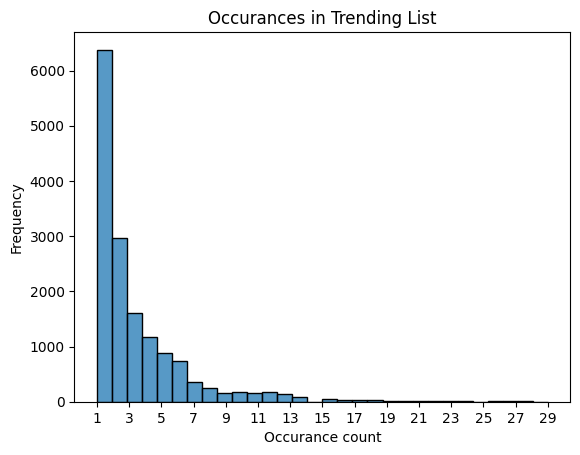

In [72]:
## Histogram of trend_rep
sns.histplot(filtrData.trend_rep[filtrData['trend_rep']>0], bins=30)

plt.xlabel('Occurance count')
plt.ylabel('Frequency')

plt.xticks(ticks=range(1, max(filtrData['trend_rep'])+1, 2))
plt.title('Occurances in Trending List')
plt.show()

In [73]:
## Counts per trending occurance (category)
filtrData.groupby("trend_cat")["trend_cat"].count().\
  rename("n").reset_index()

,trend_cat,n
0,One-time hit,15217
1,Repeat hit,15552


,0
video_id,0
publish_datetime,0
trending_date,0
title,0
channel_title,0
category,0
category_id,0
country,0
description,0
publish_date,0
